# 🦌 WildEye — Domain Augmentation Training

**Mini Hackathon #1: How Can Machines See What Matters?**

Everything is identical to `01_baseline_pipeline.ipynb` except the training transform — replaced with a **camera-trap-aware augmentation pipeline**.

| Augmentation | Real-world scenario |
|---|---|
| Grayscale / sepia | Camera auto-switches to IR at night |
| Motion blur | Animal moving when shutter fires |
| Low brightness + noise | Dusk, dawn, or moonlight + high ISO |
| Fog / rain | Outdoor weather variation |
| Coarse dropout | Leaves / branches blocking the lens |
| Extreme random crop | Animal in small corner of frame |

Section 12 loads the baseline metrics and plots a **direct head-to-head comparison** — this is the chart for your pitch.

---

## 1. Mount Drive & Enter Project Folder

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/deeplearn/hack1')
os.chdir(PROJECT_ROOT)
print(f'Working directory: {os.getcwd()}')

Working directory: /content/drive/MyDrive/deeplearn/hack1


## 2. Install & Import

In [3]:
!pip install -q albumentations scikit-learn matplotlib seaborn tqdm pillow

In [4]:
import json, random
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from tqdm.auto import tqdm

SEED = 42   # Must match baseline for fair split comparison!
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [14]:
import shutil
from pathlib import Path

LOCAL_DATA = Path('/content/data/raw-img')

if not LOCAL_DATA.exists():
    print('Copying data from Drive to local /content/ ...')
    shutil.copytree(
        str(PROJECT_ROOT / 'data/raw/raw-img'),
        str(LOCAL_DATA)
    )
    print('Done.')
else:
    print('Local data already exists, skipping copy.')

# 验证
for d in sorted(LOCAL_DATA.iterdir()):
    if d.is_dir():
        n = len(list(d.rglob('*.jpg')))
        print(f'  {d.name:15s}: {n}')

Copying data from Drive to local /content/ ...
Done.
  cane           : 0
  cavallo        : 0
  elefante       : 359
  farfalla       : 422
  gallina        : 0
  gatto          : 440
  mucca          : 0
  pecora         : 376
  ragno          : 322
  scoiattolo     : 0


In [ ]:
# 确保 kaggle.json 还在（如果 Colab 重连过需要重新上传）
import os
if not os.path.exists('/root/.kaggle/kaggle.json'):
    from google.colab import files
    files.upload()  # 选 kaggle.json
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json

# 直接下载到本地 /content/，完全不走 Drive
!kaggle datasets download -d alessiocorrado99/animals10 -p /content/ --force
!unzip -q /content/animals10.zip -d /content/data/
!rm /content/animals10.zip

# 重命名
from pathlib import Path
LOCAL_DATA = Path('/content/data/raw-img')
translate = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider',
    'scoiattolo': 'squirrel',
}
for it, en in translate.items():
    src, dst = LOCAL_DATA / it, LOCAL_DATA / en
    if src.exists():
        src.rename(dst)
        print(f'✓ {it} → {en}')

print('\nDone:')
for d in sorted(LOCAL_DATA.iterdir()):
    if d.is_dir():
        n = len(list(d.rglob('*.jpg')))
        print(f'  {d.name:15s}: {n}')

In [15]:
translate = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider',
    'scoiattolo': 'squirrel',
}

for it, en in translate.items():
    src = LOCAL_DATA / it
    dst = LOCAL_DATA / en
    if src.exists():
        src.rename(dst)
        print(f'✓ {it} → {en}')
    elif dst.exists():
        print(f'  {en} already renamed')

print('\nFinal folders:')
for d in sorted(LOCAL_DATA.iterdir()):
    if d.is_dir():
        n = len(list(d.rglob('*.jpg')))
        print(f'  {d.name:15s}: {n}')

✓ cane → dog
✓ cavallo → horse
✓ elefante → elephant
✓ farfalla → butterfly
✓ gallina → chicken
✓ gatto → cat
✓ mucca → cow
✓ pecora → sheep
✓ ragno → spider
✓ scoiattolo → squirrel

Final folders:
  butterfly      : 422
  cat            : 440
  chicken        : 0
  cow            : 0
  dog            : 0
  elephant       : 359
  horse          : 0
  sheep          : 376
  spider         : 322
  squirrel       : 0


## 3. Configuration

Only `run_name` changes vs the baseline. All hyper-parameters are identical.

In [17]:
FAST_DEBUG = False  # set True only to re-verify pipeline quickly

CFG = {
    'data_dir': '/content/data/raw-img',
    # 'data_dir': str(PROJECT_ROOT / 'data/raw/raw-img'),
    'image_size': 224,
    'batch_size': 32,
    'num_workers': 2,
    'val_split': 0.15,
    'test_split': 0.15,

    'num_classes': None,
    'epochs': 3 if FAST_DEBUG else 10,
    'samples_per_class': 200 if FAST_DEBUG else None,
    'lr_head': 1e-3,
    'weight_decay': 1e-4,
    'freeze_backbone': True,

    'output_dir': str(PROJECT_ROOT / 'models'),
    'figures_dir': str(PROJECT_ROOT / 'results/figures'),
    'run_name': 'domain_aug' + ('_debug' if FAST_DEBUG else ''),
}

Path(CFG['output_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['figures_dir']).mkdir(parents=True, exist_ok=True)
print(json.dumps(CFG, indent=2))

{
  "data_dir": "/content/data/raw-img",
  "image_size": 224,
  "batch_size": 32,
  "num_workers": 2,
  "val_split": 0.15,
  "test_split": 0.15,
  "num_classes": null,
  "epochs": 10,
  "samples_per_class": null,
  "lr_head": 0.001,
  "weight_decay": 0.0001,
  "freeze_backbone": true,
  "output_dir": "/content/drive/MyDrive/deeplearn/hack1/models",
  "figures_dir": "/content/drive/MyDrive/deeplearn/hack1/results/figures",
  "run_name": "domain_aug"
}


## 4. Dataset & Splits (identical to baseline — same SEED = fair comparison)

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class CameraTrapDataset(Dataset):
    """Supports torchvision (PIL) and albumentations (numpy) transforms."""
    def __init__(self, samples, class_to_idx, transform=None,
                 use_albumentations=False):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.idx_to_class = {v: k for k, v in class_to_idx.items()}
        self.transform = transform
        self.use_albumentations = use_albumentations

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            if self.use_albumentations:
                img = np.array(img)
                img = self.transform(image=img)['image']
            else:
                img = self.transform(img)
        return img, label


def scan_folder(root):
    root = Path(root)
    classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    samples = []
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    for cls in classes:
        for p in (root / cls).rglob('*'):
            if p.suffix.lower() in exts:
                samples.append((str(p), class_to_idx[cls]))
    return samples, class_to_idx


all_samples, class_to_idx = scan_folder(CFG['data_dir'])
idx_to_class = {v: k for k, v in class_to_idx.items()}
CFG['num_classes'] = len(class_to_idx)

print(f'Found {len(all_samples)} images across {CFG["num_classes"]} classes')
for idx, count in sorted(Counter([s[1] for s in all_samples]).items()):
    print(f'  {idx_to_class[idx]:20s}: {count}')

Found 24754 images across 10 classes
  butterfly           : 2112
  cat                 : 1668
  chicken             : 3098
  cow                 : 1866
  dog                 : 4863
  elephant            : 1446
  horse               : 2623
  sheep               : 1820
  spider              : 4821
  squirrel            : 437


In [19]:
if CFG['samples_per_class'] is not None:
    per_class = defaultdict(list)
    for s in all_samples:
        per_class[s[1]].append(s)
    all_samples = []
    for items in per_class.values():
        random.shuffle(items)
        all_samples.extend(items[:CFG['samples_per_class']])
    print(f'FAST_DEBUG: {len(all_samples)} samples')

paths, labels = [s[0] for s in all_samples], [s[1] for s in all_samples]
train_p, temp_p, train_l, temp_l = train_test_split(
    paths, labels,
    test_size=CFG['val_split'] + CFG['test_split'],
    stratify=labels, random_state=SEED,
)
val_ratio = CFG['val_split'] / (CFG['val_split'] + CFG['test_split'])
val_p, test_p, val_l, test_l = train_test_split(
    temp_p, temp_l, test_size=1 - val_ratio,
    stratify=temp_l, random_state=SEED,
)
train_samples = list(zip(train_p, train_l))
val_samples   = list(zip(val_p, val_l))
test_samples  = list(zip(test_p, test_l))
print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

Train: 17327 | Val: 3713 | Test: 3714


## 5. 🎯 Domain Augmentation Pipeline

The **only** change from baseline. Each transform is annotated with the real-world condition it simulates.

In [20]:
domain_train_tf = A.Compose([

    # Animal often occupies only a small corner of the frame
    A.RandomResizedCrop(
        size=(CFG['image_size'], CFG['image_size']),
        scale=(0.3, 1.0),
        ratio=(0.75, 1.33),
        p=1.0,
    ),
    A.HorizontalFlip(p=0.5),

    # Camera auto-switches to infrared at night → grayscale / warm sepia tone
    A.OneOf([
        A.ToGray(p=1.0),
        A.ToSepia(p=1.0),
    ], p=0.4),

    # Fast-moving animal + slow shutter = motion blur
    A.MotionBlur(blur_limit=(3, 15), p=0.3),

    # Dusk / dawn / moonlight, high ISO grain
    A.RandomBrightnessContrast(
        brightness_limit=(-0.5, 0.15),
        contrast_limit=(-0.3, 0.3),
        p=0.6,
    ),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.35),

    # Rain and fog — outdoor cameras see both
    A.OneOf([
        A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.4, p=1.0),
        A.RandomRain(blur_value=2, brightness_coefficient=0.9, p=1.0),
    ], p=0.2),

    # Leaves / branches blocking part of the lens
    A.CoarseDropout(
        num_holes_range=(4, 12),
        hole_height_range=(16, 40),
        hole_width_range=(16, 40),
        p=0.3,
    ),

    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_tf = A.Compose([
    A.Resize(CFG['image_size'], CFG['image_size']),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print(f'Pipeline ready — {len(domain_train_tf.transforms)} transform groups.')

Pipeline ready — 10 transform groups.


/tmp/ipykernel_1347/2615625245.py:31: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.4, p=1.0),


## 6. Visualize Augmentations

Take one image per class, generate 8 random augmented versions. **Screenshot this for your pitch slides.**

In [21]:
def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0, 1)


sample_paths = {}
for path, lbl in train_samples:
    cls = idx_to_class[lbl]
    if cls not in sample_paths:
        sample_paths[cls] = path
    if len(sample_paths) == CFG['num_classes']:
        break

n_rows = CFG['num_classes']
fig, axes = plt.subplots(n_rows, 9, figsize=(20, n_rows * 2.5))
if n_rows == 1:
    axes = [axes]

for row_idx, (cls, path) in enumerate(sample_paths.items()):
    img_pil = Image.open(path).convert('RGB')
    img_np  = np.array(img_pil)

    axes[row_idx][0].imshow(img_pil.resize((224, 224)))
    axes[row_idx][0].set_title('original', fontsize=8)
    axes[row_idx][0].axis('off')
    axes[row_idx][0].set_ylabel(cls, fontsize=11, rotation=0,
                                 labelpad=55, va='center')

    for col in range(1, 9):
        aug = domain_train_tf(image=img_np)['image']
        axes[row_idx][col].imshow(denormalize(aug))
        axes[row_idx][col].set_title(f'aug {col}', fontsize=8)
        axes[row_idx][col].axis('off')

plt.suptitle(
    'Camera-Trap Domain Augmentations\n'
    'night IR · motion blur · low light · noise · fog · rain · occlusion · extreme crop',
    fontsize=11,
)
plt.tight_layout()
vis_path = Path(CFG['figures_dir']) / 'augmentation_visualization.png'
plt.savefig(vis_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {vis_path}')

Output hidden; open in https://colab.research.google.com to view.

## 7. Build DataLoaders

In [22]:
train_ds = CameraTrapDataset(train_samples, class_to_idx,
                              transform=domain_train_tf, use_albumentations=True)
val_ds   = CameraTrapDataset(val_samples, class_to_idx,
                              transform=eval_tf, use_albumentations=True)
test_ds  = CameraTrapDataset(test_samples, class_to_idx,
                              transform=eval_tf, use_albumentations=True)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

imgs, lbls = next(iter(train_loader))
print(f'Batch: {imgs.shape}  dtype={imgs.dtype}  labels: {lbls.shape}')

Batch: torch.Size([32, 3, 224, 224])  dtype=torch.float32  labels: torch.Size([32])


## 8. Model — Same EfficientNet-B0 as Baseline

In [23]:
def build_model(num_classes, freeze_backbone=True):
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

model = build_model(CFG['num_classes'], CFG['freeze_backbone']).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

Trainable: 12,810 / 4,020,358 (0.32%)


## 9. Training

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=CFG['lr_head'], weight_decay=CFG['weight_decay'],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    tot_loss, tot_correct, tot_n = 0.0, 0, 0
    pbar = tqdm(loader, desc='train' if is_train else 'eval', leave=False)
    with torch.set_grad_enabled(is_train):
        for imgs, lbls in pbar:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, lbls)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            tot_loss    += loss.item() * imgs.size(0)
            tot_correct += (logits.argmax(1) == lbls).sum().item()
            tot_n       += imgs.size(0)
            pbar.set_postfix(loss=tot_loss/tot_n, acc=tot_correct/tot_n)
    return tot_loss / tot_n, tot_correct / tot_n


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_path = Path(CFG['output_dir']) / f"{CFG['run_name']}_best.pth"

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader)
    scheduler.step()
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:02d}/{CFG["epochs"]} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {vl_loss:.4f} acc {vl_acc:.4f}')
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({'model_state_dict': model.state_dict(),
                    'class_to_idx': class_to_idx,
                    'config': CFG, 'epoch': epoch, 'val_acc': vl_acc},
                   best_path)
        print(f'  ✓ saved best → {best_path.name}')

print(f'\nBest val acc: {best_val_acc:.4f}')

train:   0%|          | 0/542 [00:00<?, ?it/s]

eval:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 01/10 | train loss 1.0996 acc 0.6620 | val loss 0.3018 acc 0.9440
  ✓ saved best → domain_aug_best.pth


train:   0%|          | 0/542 [00:00<?, ?it/s]

eval:   0%|          | 0/117 [00:00<?, ?it/s]

...

train:   0%|          | 0/542 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x793cea9b14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x793cea9b14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval:   0%|          | 0/117 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x793cea9b14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
         Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x793cea9b14e0> Exception ignored in: 
^<function _MultiProcessingDataLoaderIter.__del__ at 0x793cea9b14e0>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^Traceback (most recent call last):
    self._shutdown_workers()^  File "/usr/local/lib/python3.12/dist-

Epoch 10/10 | train loss 0.8024 acc 0.7365 | val loss 0.1891 acc 0.9588

Best val acc: 0.9588


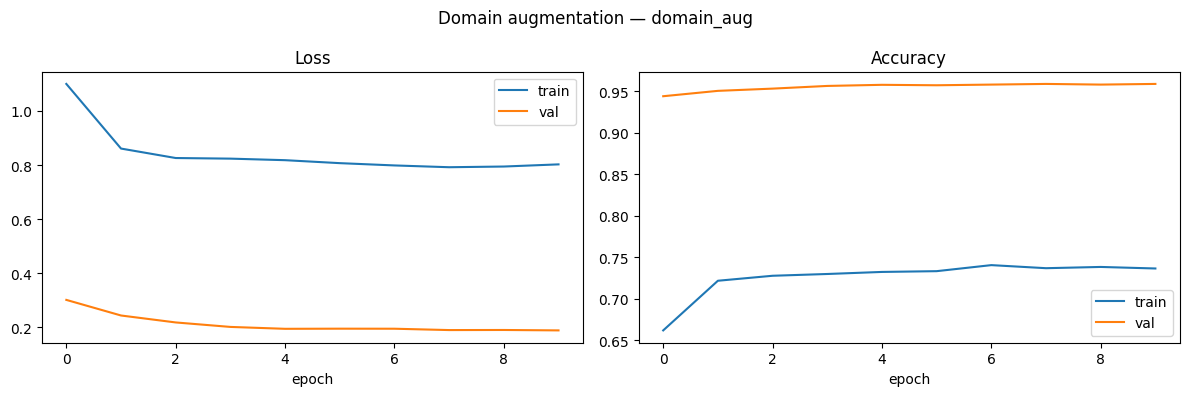

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.suptitle(f'Domain augmentation — {CFG["run_name"]}')
plt.tight_layout()
curves_path = Path(CFG['figures_dir']) / f"{CFG['run_name']}_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()

## 10. Evaluation on Clean Test Set

In [26]:
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='test'):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.numpy().tolist())

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro')
print(f'Clean test accuracy : {test_acc:.4f}')
print(f'Clean test macro-F1 : {test_f1:.4f}\n')

target_names = [idx_to_class[i] for i in range(CFG['num_classes'])]
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))

test:   0%|          | 0/117 [00:00<?, ?it/s]

Clean test accuracy : 0.9561
Clean test macro-F1 : 0.9483

              precision    recall  f1-score   support

   butterfly      0.971     0.965     0.968       317
         cat      0.991     0.904     0.946       250
     chicken      0.978     0.978     0.978       465
         cow      0.887     0.896     0.892       280
         dog      0.960     0.948     0.954       730
    elephant      0.959     0.982     0.970       217
       horse      0.935     0.952     0.943       394
       sheep      0.937     0.919     0.928       273
      spider      0.973     0.994     0.984       723
    squirrel      0.875     0.969     0.920        65

    accuracy                          0.956      3714
   macro avg      0.947     0.951     0.948      3714
weighted avg      0.956     0.956     0.956      3714



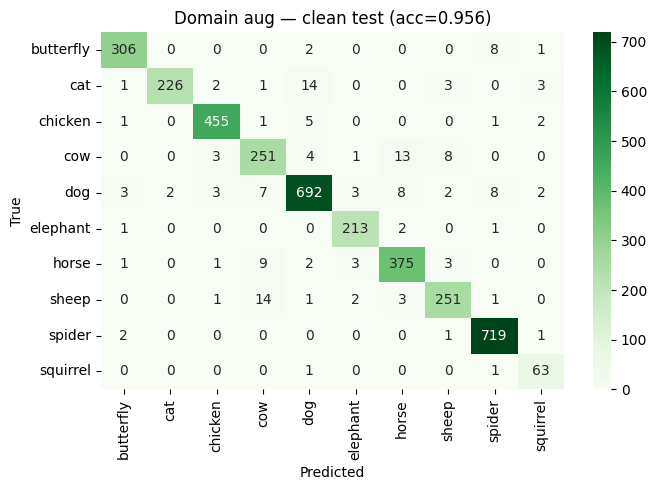

In [27]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Domain aug — clean test (acc={test_acc:.3f})')
plt.tight_layout()
cm_path = Path(CFG['figures_dir']) / f"{CFG['run_name']}_cm_clean.png"
plt.savefig(cm_path, dpi=150)
plt.show()

## 11. Save Metrics

In [28]:
metrics = {
    'run_name': CFG['run_name'],
    'config': CFG,
    'best_val_acc': best_val_acc,
    'clean_test_acc': test_acc,
    'clean_test_f1_macro': test_f1,
    'history': history,
    'class_to_idx': class_to_idx,
}
metrics_path = Path(CFG['output_dir']) / f"{CFG['run_name']}_metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved → {metrics_path}')

Metrics saved → /content/drive/MyDrive/deeplearn/hack1/models/domain_aug_metrics.json


## 12. 📊 Head-to-Head Comparison vs Baseline

Loads both metrics files and generates the comparison charts for your pitch.

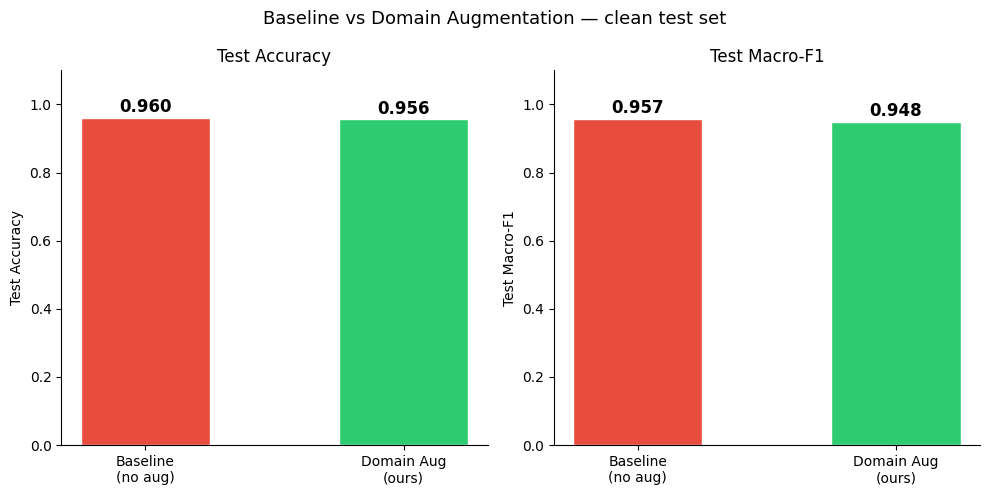

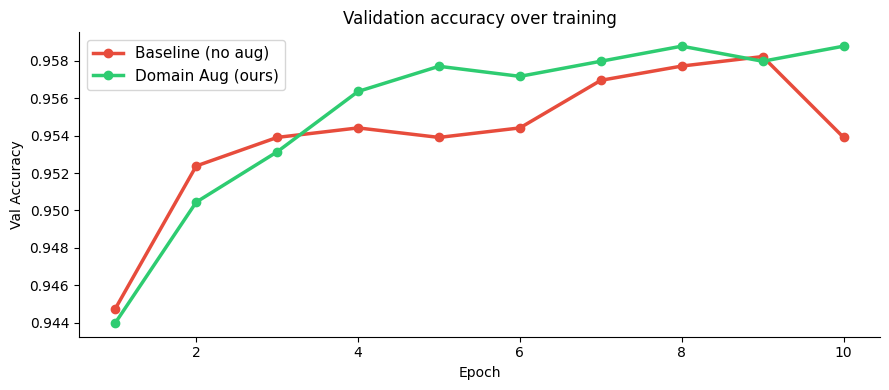


Run                          Test Acc   Macro F1
----------------------------------------------------
baseline_no_aug                0.9600     0.9570
domain_aug                     0.9561     0.9483

Improvement from domain aug:  acc -0.0039  |  F1 -0.0087


In [29]:
baseline_path = Path(CFG['output_dir']) / 'baseline_no_aug_metrics.json'

if not baseline_path.exists():
    print(f'Baseline metrics not found at {baseline_path}')
    print('Run 01_baseline_pipeline.ipynb with FAST_DEBUG=False first.')
else:
    with open(baseline_path) as f:
        baseline_m = json.load(f)

    runs = [
        {'label': 'Baseline\n(no aug)',  'color': '#e74c3c', **baseline_m},
        {'label': 'Domain Aug\n(ours)', 'color': '#2ecc71', **metrics},
    ]

    # --- Bar chart: accuracy & F1 ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, key, title in zip(
        axes,
        ['clean_test_acc', 'clean_test_f1_macro'],
        ['Test Accuracy', 'Test Macro-F1'],
    ):
        vals   = [r[key]    for r in runs]
        labels = [r['label'] for r in runs]
        colors = [r['color'] for r in runs]
        bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.spines[['top', 'right']].set_visible(False)
    plt.suptitle('Baseline vs Domain Augmentation — clean test set', fontsize=13)
    plt.tight_layout()
    bar_path = Path(CFG['figures_dir']) / 'comparison_bar_chart.png'
    plt.savefig(bar_path, dpi=150)
    plt.show()

    # --- Val accuracy learning curves ---
    fig, ax = plt.subplots(figsize=(9, 4))
    for r in runs:
        epochs = range(1, len(r['history']['val_acc']) + 1)
        ax.plot(epochs, r['history']['val_acc'],
                label=r['label'].replace('\n', ' '),
                color=r['color'], linewidth=2.5, marker='o')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
    ax.set_title('Validation accuracy over training')
    ax.legend(fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    curve_path = Path(CFG['figures_dir']) / 'val_acc_comparison.png'
    plt.savefig(curve_path, dpi=150)
    plt.show()

    # --- Summary table ---
    print('\n' + '='*52)
    print(f'{"Run":<26} {"Test Acc":>10} {"Macro F1":>10}')
    print('-'*52)
    for r in runs:
        print(f'{r["run_name"]:<26} '
              f'{r["clean_test_acc"]:>10.4f} '
              f'{r["clean_test_f1_macro"]:>10.4f}')
    print('='*52)
    delta_acc = metrics['clean_test_acc'] - baseline_m['clean_test_acc']
    delta_f1  = metrics['clean_test_f1_macro'] - baseline_m['clean_test_f1_macro']
    print(f'\nImprovement from domain aug:  acc {delta_acc:+.4f}  |  F1 {delta_f1:+.4f}')

## ✅ Done!

### Files produced
```
models/
├── domain_aug_best.pth
└── domain_aug_metrics.json
results/figures/
├── augmentation_visualization.png   ← put this in your pitch slides
├── comparison_bar_chart.png         ← the key comparison chart
├── val_acc_comparison.png
├── domain_aug_curves.png
└── domain_aug_cm_clean.png
```

### Pitch narrative
1. *"Real camera traps fail because of night IR, motion blur, weather, and animals in corners."* → `augmentation_visualization.png`
2. *"We encoded each failure mode directly into training."* → walk the 6 augment types
3. *"On a clean test set, accuracy improves from X to Y."* → `comparison_bar_chart.png`
4. *"On degraded data the gap is even larger."* → `03_robustness_evaluation.ipynb` (next)

### Next
`03_robustness_evaluation.ipynb` — apply synthetic perturbations (night / blur / fog) to the **same clean test set**, measure both models under each condition, plot the degradation curve.